# Assignment: Data Analysis of Vital Signs in Surgical Patients using VitalDB

## Domain Relevance
Monitoring vital signs is crucial in evaluating a patient's physiological state during surgical interventions. VitalDB, an extensive repository, offers access to detailed vital sign data recorded from surgical patients. This assignment aims to harness previously acquired skills by developing a client application for processing and analyzing vital signs data. 

## About the data
The VitalDB (Vital Signs DataBase) is an open dataset created specifically to facilitate machine learning studies related to monitoring vital signs in surgical patients. This dataset contains high-resolution multi-parameter data from 6,388 cases, including 486,451 waveform and numeric data tracks of 196 intraoperative monitoring parameters, 73 perioperative clinical parameters, and 34 time-series laboratory result parameters. All data is stored in the public cloud after anonymization. The dataset can be freely accessed and analysed using application programming interfaces and Python library[1,2,3]. Documentation about the vitalDB can be found here: https://physionet.org/content/vitaldb/1.0.0/vital_files/#files-panel

[Info about Recording Devices](https://www.nature.com/articles/s41597-022-01411-5/tables/3)


---
## Learning outcomes

1. You get proficiency in interpreting instructions and documentation to access data from non-standard sources, such as VitalDB.
2.	You demonstrate a high level of competence in applying python and relevant libraries as well as appropriate mathematical, and statistical methods to effectively identify patterns, causal relationships, and actionable insights.
3.	You adeptly select appropriate data analysis methods, provide sound justifications for your choice, or creatively adapt existing methods to develop solutions for the problems. 
4.	You can integrate diverse knowledge domains, effectively handle complexity, and extract meaningful information from data, even in the presence of incomplete or challenging datasets. 
5.	You develop a maintainable well-structured solution comprising modules for parsing, feature extraction, analysis, and visualization of signal data. You adhere to [the fair principles](https://en.wikipedia.org/wiki/FAIR_data). Your code is organized, well written, well documented, traceable via version control management systems, and suitably licensed. 

--- 

## Instructions
- Read [the assessment](#assessment-criteria) criteria carefully.
- Conduct the tasks [as described below](#tasks).
- Upload the solution of this study case in a repository and submit the link to the blackboard assignment. Make sure that your repository is private and invite your teachers and tutors.
- Make sure that you do not upload data and or API Keys to your repository. Make use of a config-file and write instructions in the readme how to access the data.
- Ensure that you acknowledge other persons's contributions and/or usage of AI tools.

---


## Assessment Criteria:

* **Data Quality and Quantity (15 pt):** Rigorous evaluation of data quality, emphasizing accuracy, completeness, and consistency for time series analysis. Python code, leveraging Pandas and Numpy libraries, implements specialized preprocessing steps tailored for time series datasets.

* **Interactive Visualization (10 pt):** Develop interactive visualizations with a temporal perspective, incorporating time-specific axes, intervals, and trends. Captions provide insights into time-related patterns, ensuring clarity and relevance to time series characteristics.

* **Design Alignment and Functionality (10 pt):** Project design aligns with time series research questions. The information extracted from time series data is presented in a manner that is insightful and pertinent. Tables and visualizations emphasize temporal patterns, offering a strong foundation for time series-focused research conclusions.

* **Maintainable solution (20 pt):** Programming code is logically organized in modules, classess are implemented to support efficiency, readability and maintainability.

* **Efficient and Error-free Code (10 pt):** Code adheres to coding standards, ensuring efficiency, readability, and error-free processing. The code aims for maintainability and flexibility, allowing for future modifications without compromising functionality.

* **Repository and Documentation (10 pt):** All code is stored in a repository with a comprehensive README file. The README emphasizes implementation details specific to time series analysis, addressing nuances in the data and methodologies. The codebase is well-documented, facilitating easy understanding and implementation

* **Conduct Critical Research (20 pt):** Transparently state assumptions, justifying design choices with a focus on time series-specific considerations.  Argumentative documentation within the code or separate document, critically questioning and engaging with elements crucial for time series analysis.

* **References (5 pt):** Clearly documented references, following scientific citation standards, highlighting their relevance to time series analysis methodologies and techniques.

---
## References
[1] Lee, H., & Jung, C. (2022). VitalDB, a high-fidelity multi-parameter vital signs database in surgical patients (version 1.0.0). PhysioNet. https://doi.org/10.13026/czw8-9p62.

[2] Lee, HC., Park, Y., Yoon, S.B. et al. VitalDB, a high-fidelity multi-parameter vital signs database in surgical patients. Sci Data 9, 279 (2022)

[3] Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220.

# Data Acquisition and Preparation
- Read the instructions provided to access VitalDB and select one of the datasets.
- Identify at least two vital signals (tracks) from the chosen dataset for univariate and multivariate signal analysis. Choose signals that are clinical relevant to analyse together. 
- Thoroughly inspect and clean the dataset, addressing datatype formats, missing values, outliers, and other anomalies.
- Using the insights from the previous steps, construct a parser module (python script that loads, cleans and reformat the data into a required format).
  
**Deliverable: Parser module**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scripts.parser import load_data, data_info, preprocess_vital_signs
from scripts.visualization import static_plot_vitals, create_dynamic_time_series_plot
from scripts.analysis import analyze_vital_signs
from datetime import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

Module 'scripts.parser' is imported successfully!
Module 'scripts.visualization' is imported successfully!
Module 'scripts.analysis' is imported successfully!


In [3]:
# setting variables for the vital signs
SYS = 'Solar8000/ART_SBP'
DIA = 'Solar8000/ART_DBP'
HRT = 'Solar8000/HR'

In [4]:
# Load Data: Takes a few seconds as the data size is relatively large
vitals = load_data('vitaldb')

In [5]:
data_info(vitals)

Number of duplicate indices: 0
Number of duplicate rows: 19260
Number of NaN values in the DataFrame: 2793

<class 'pandas.core.frame.DataFrame'>
Index: 29582 entries, 00:00:00 to 16:26:02
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Solar8000/ART_SBP  28327 non-null  float64
 1   Solar8000/ART_DBP  28348 non-null  float64
 2   Solar8000/HR       29278 non-null  float64
 3   EVENT              4 non-null      object 
dtypes: float64(3), object(1)
memory usage: 2.1+ MB


What we can see from the data info and the dataframe itself is:

- The data is recorded every two seconds.

- The first and last few rows are empty which are after the EVENT = case started, and before EVENT = Case finished. This can indicate the connecting / disconnecting the monitoring devices.

- Number of duplicate rows: 19260 and Number of duplicate indices: 0 shows that there are no indices (timestamps) repeating due to error but the values of the rows happen to be identical for multiple rows. Given the nature and range of the Blood Pressure and Heart Rate, I don't think it's a cause of concern, as they may remain the same if the patient is stable. So I won't do anything about them.

- There are also nan values during the surgery which we will probably need to impute.

- In the next step we visualize the data to get a better overview of data distribution, and take further steps in preprocessing.


# Visualization
- Visualize the vital signal information using appropriate visualization techniques.
  
**Deliverable: visualization module**

Plot saved as Solar8000_ART_DBP_plot.png


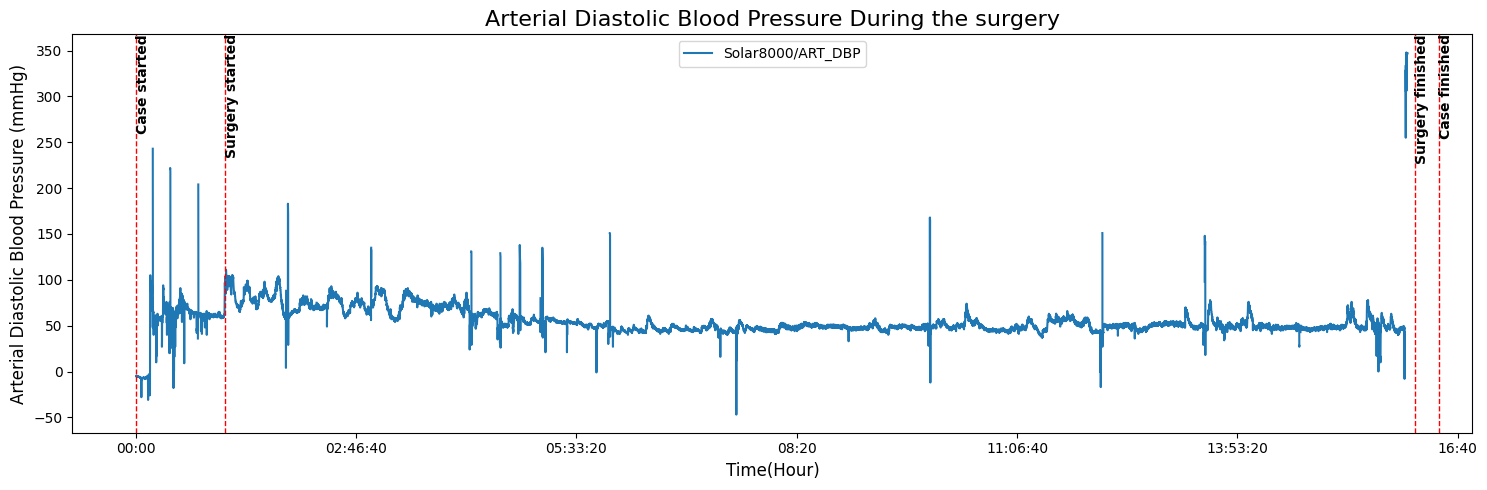

Plot saved as Solar8000_ART_SBP_plot.png


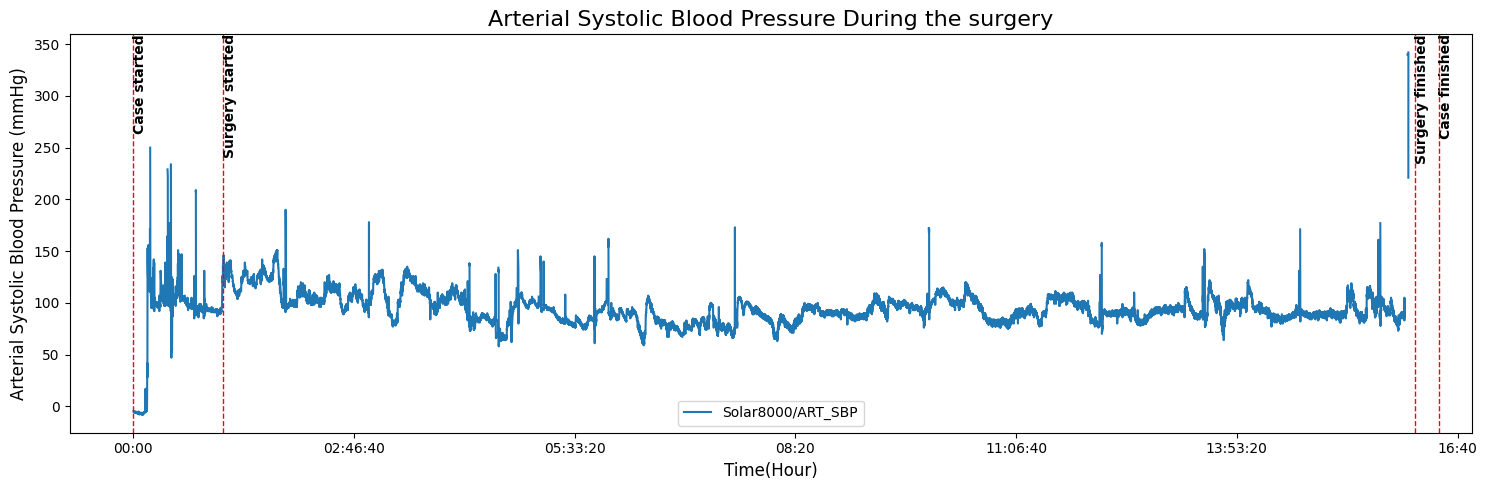

Plot saved as Solar8000_HR_plot.png


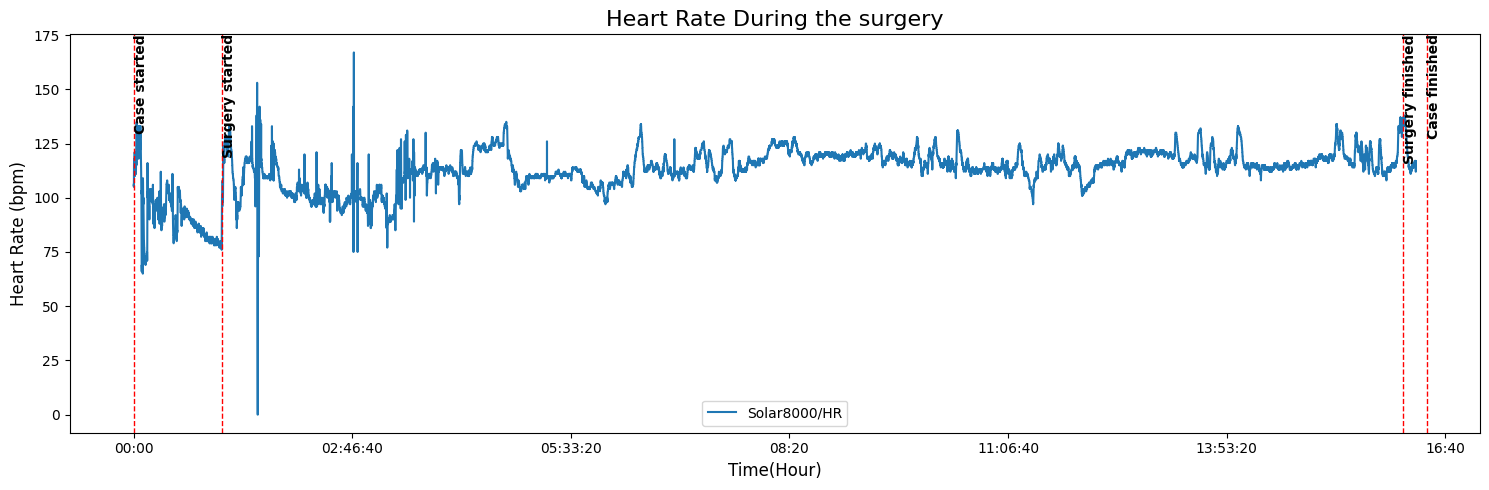

In [6]:
static_plot_vitals(vitals, save_file=True)

In [7]:
create_dynamic_time_series_plot(vitals,SYS, show_nans=True,file_save=True)
create_dynamic_time_series_plot(vitals, DIA, show_nans=True,file_save=True)
create_dynamic_time_series_plot(vitals, HRT,show_nans=True,file_save=True)

Launching server at http://localhost:37503
Launching server at http://localhost:39923
Launching server at http://localhost:38687


By inspecting the static and dynamic plots we can see:
- There are out of range values.  
- There are null values that require special handling.  

So more advanced preprocessing is needed.

In [8]:
# We care about the data during the surgery as the connecting/disconnecting devices part are not relevant for our analysis; they are artifacts.
start = vitals[vitals['EVENT']== 'Surgery started'].index[0]
end = vitals[vitals['EVENT']== 'Surgery finished'].index[0]

I decided **not** to exclude outliers that are still within the reasonable range. Because vital signs' significant peaks or drops are possible during the surgery, for example heart rate drops, particularly during laparoscopy or with specific anesthetic agents, is possible. Vigilance for bradycardia as an early warning sign (even in healthy patients) and rapid intervention are critical to prevent progression to cardiac arrest.[source](https://www.anaesthesiacollective.com/bradycardias-during-anaesthesia/)

In [9]:
vitals_c = vitals.copy()
vitals_no_event = vitals_c.loc[start:end]
vitals_no_event.loc[:, HRT], hr_nan = preprocess_vital_signs(vitals_no_event[HRT], 'hr')
vitals_no_event.loc[:, DIA], dia_nan = preprocess_vital_signs(vitals_no_event[DIA], 'dbp')
vitals_no_event.loc[:,SYS], sys_nan = preprocess_vital_signs(vitals_no_event[SYS], 'sbp')

Number of NaN values : 53    This is 0.20% of the data
Linearly Interpolated with limit:10
Number of NaN values : 0    This is 0.00% of the data
No NaN values found after interpolation


Number of NaN values : 704    This is 2.61% of the data
Linearly Interpolated with limit:10
Number of NaN values : 320    This is 1.19% of the data
Chained Forward-Backward fill with limit: 5
Number of NaN values : 235    This is 0.87% of the data
Filled Nans with Exponentially Weighted Moving Average, with the span of 30 samples
Number of NaN values : 0    This is 0.00% of the data


Number of NaN values : 631    This is 2.34% of the data
Linearly Interpolated with limit:10
Number of NaN values : 259    This is 0.96% of the data
Chained Forward-Backward fill with limit: 5
Number of NaN values : 165    This is 0.61% of the data
Filled Nans with Exponentially Weighted Moving Average, with the span of 30 samples
Number of NaN values : 0    This is 0.00% of the data




Below we can see the consecutive gaps, their sample counts, start, end and duration.

In [10]:
hr_nan = hr_nan.sort_values(by ='count', ascending=False)
# hr_nan.to_csv('hr_nan.csv', index=False)
hr_nan.head(10)

,count,start_time,end_time,duration
1,10,0 days 02:16:42,0 days 02:17:00,0 days 00:00:19
3,10,0 days 07:16:50,0 days 07:17:08,0 days 00:00:19
15,9,0 days 12:17:00,0 days 12:17:16,0 days 00:00:17
0,8,0 days 01:34:26,0 days 01:34:40,0 days 00:00:15
2,1,0 days 06:17:54,0 days 06:17:54,0 days 00:00:01
4,1,0 days 07:56:24,0 days 07:56:24,0 days 00:00:01
6,1,0 days 07:56:34,0 days 07:56:34,0 days 00:00:01
5,1,0 days 07:56:30,0 days 07:56:30,0 days 00:00:01
8,1,0 days 07:56:48,0 days 07:56:48,0 days 00:00:01
9,1,0 days 07:56:56,0 days 07:56:56,0 days 00:00:01


In [11]:
dia_nan= dia_nan.sort_values(by ='count', ascending=False)
# dia_nan.to_csv('dia_nan.csv', index=False)
dia_nan.head(10)

,count,start_time,end_time,duration
59,229,0 days 16:00:04,0 days 16:07:40,0 days 00:07:37
43,40,0 days 12:09:56,0 days 12:11:14,0 days 00:01:19
1,36,0 days 01:53:38,0 days 01:54:48,0 days 00:01:11
13,33,0 days 05:06:08,0 days 05:07:12,0 days 00:01:05
9,32,0 days 04:34:18,0 days 04:35:20,0 days 00:01:03
56,27,0 days 15:40:20,0 days 15:41:12,0 days 00:00:53
4,27,0 days 02:58:02,0 days 02:58:54,0 days 00:00:53
48,26,0 days 13:27:48,0 days 13:28:38,0 days 00:00:51
12,25,0 days 04:49:28,0 days 04:50:16,0 days 00:00:49
19,25,0 days 05:57:30,0 days 05:58:18,0 days 00:00:49


In [12]:
sys_nan = sys_nan.sort_values(by ='count', ascending=False)
sys_nan.to_csv('sys_nan.csv', index=False)
sys_nan.head(10)

,count,start_time,end_time,duration
39,145,0 days 16:02:52,0 days 16:07:40,0 days 00:04:49
34,54,0 days 16:00:08,0 days 16:01:54,0 days 00:01:47
0,36,0 days 01:53:38,0 days 01:54:48,0 days 00:01:11
8,33,0 days 05:06:08,0 days 05:07:12,0 days 00:01:05
5,32,0 days 04:34:18,0 days 04:35:20,0 days 00:01:03
25,30,0 days 12:10:14,0 days 12:11:12,0 days 00:00:59
2,27,0 days 02:58:02,0 days 02:58:54,0 days 00:00:53
31,27,0 days 15:40:20,0 days 15:41:12,0 days 00:00:53
27,26,0 days 13:27:48,0 days 13:28:38,0 days 00:00:51
3,25,0 days 04:12:38,0 days 04:13:26,0 days 00:00:49


We can see that most consecutive nan values are related to the end of the surgery, probably when they were unhooking the devices.
As the total percentage of the missing values is under 3% for each signal, the methods we have used for imputation, although crude, can be considered acceptable.

I decided not to use detrending, as I think it's important to notice the long-term changes in vital signs during the surgery. They are essential for understanding the patient’s physiological state, detecting complications early, and guiding intraoperative and postoperative care.

Although the option of smoothing is implemented, I decided not to use it as I want to take into account all the fluctuations for later analysis, and the sampling time is 2 seconds, so the samples are not very close to each other in time. However, this option can be used for seeing trends more clearly.

In [13]:
vitals_no_event

,Solar8000/ART_SBP,Solar8000/ART_DBP,Solar8000/HR,EVENT
01:07:40,136.000000,104.000000,104.0,Surgery started
01:07:42,134.000000,91.000000,106.0,NaN
01:07:44,134.000000,97.000000,106.0,NaN
01:07:46,134.000000,97.000000,107.0,NaN
01:07:48,137.000000,97.000000,107.0,NaN
...,...,...,...,...
16:07:32,183.459294,43.704453,135.0,NaN
16:07:34,183.459294,43.704453,135.0,NaN
16:07:36,183.459294,43.704453,137.0,NaN
16:07:38,183.459294,43.704453,136.0,NaN


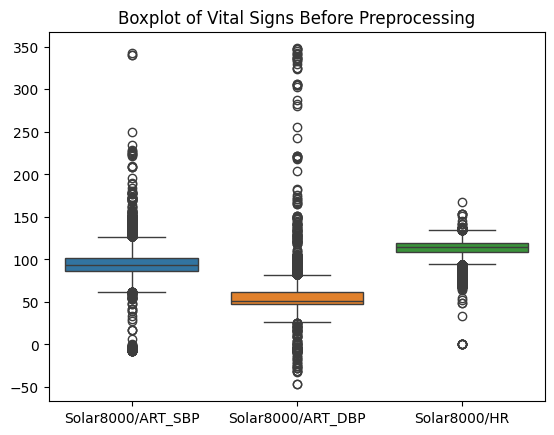

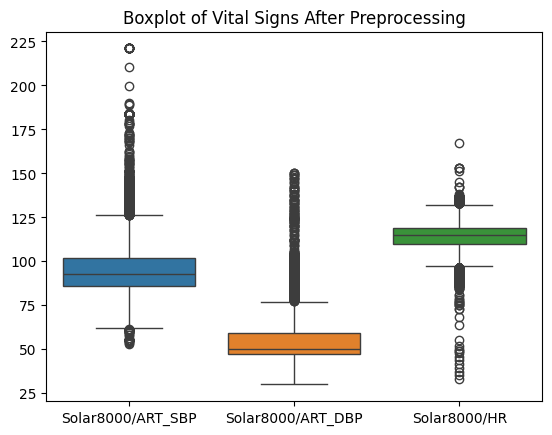

In [14]:
sns.boxplot(vitals).set_title('Boxplot of Vital Signs Before Preprocessing')
plt.show()

sns.boxplot(vitals_no_event).set_title('Boxplot of Vital Signs After Preprocessing')
plt.show()


In [15]:
vitals_no_event.describe()

,Solar8000/ART_SBP,Solar8000/ART_DBP,Solar8000/HR
count,27001.000000,27001.000000,27001.000000
mean,95.451441,55.434722,114.219529
std,15.720384,13.063381,8.001323
min,53.000000,30.000000,33.000000
25%,86.000000,47.000000,110.000000
50%,93.000000,50.000000,115.000000
75%,102.000000,59.000000,119.000000
max,221.000000,150.000000,167.000000


In [16]:
vitals.describe()

,Solar8000/ART_SBP,Solar8000/ART_DBP,Solar8000/HR
count,28327.000000,28348.000000,29278.000000
mean,94.070886,55.521765,112.751998
std,17.777320,17.278702,10.247286
min,-8.000000,-47.000000,0.000000
25%,86.000000,47.000000,109.000000
50%,93.000000,51.000000,114.000000
75%,102.000000,61.000000,119.000000
max,342.000000,348.000000,167.000000


BEFORE PRE-PROCESSING



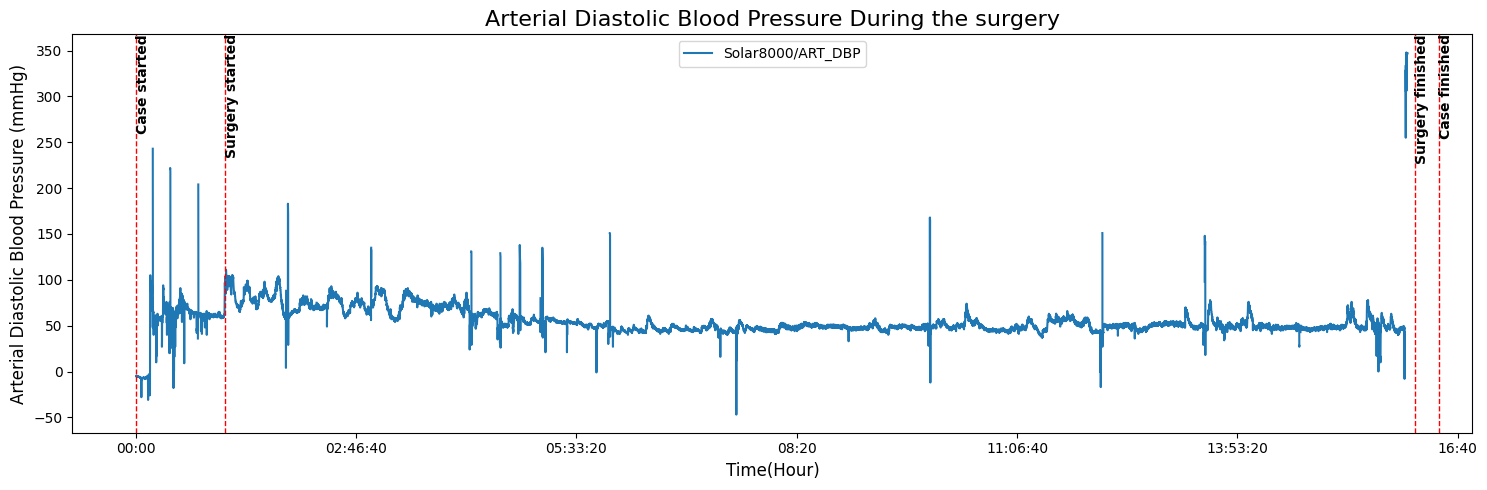

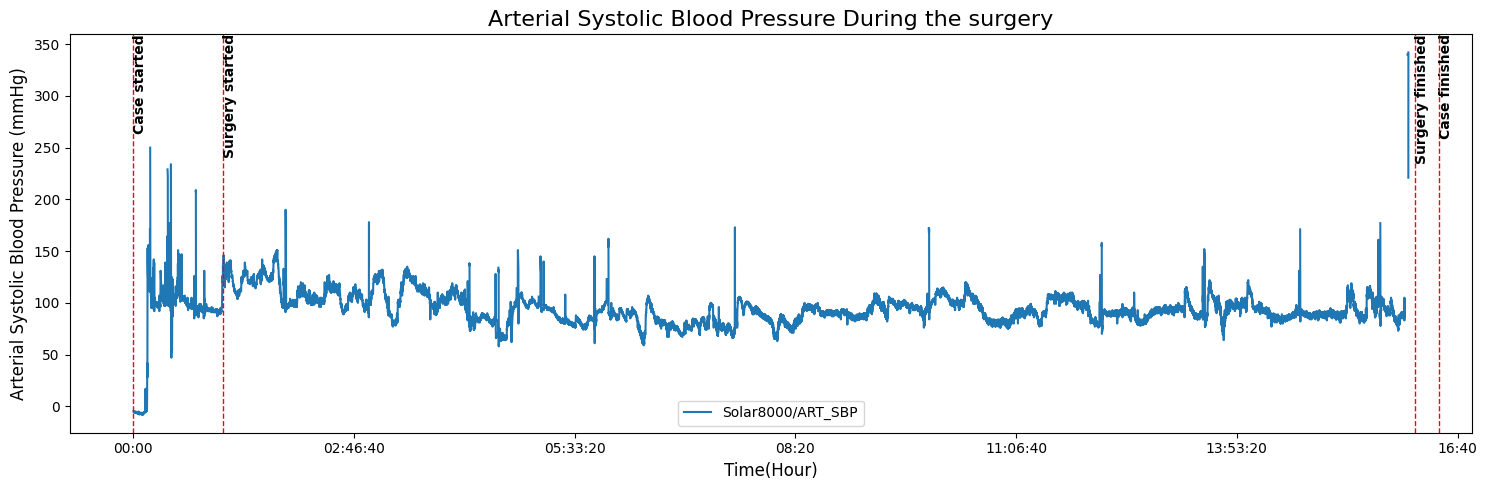

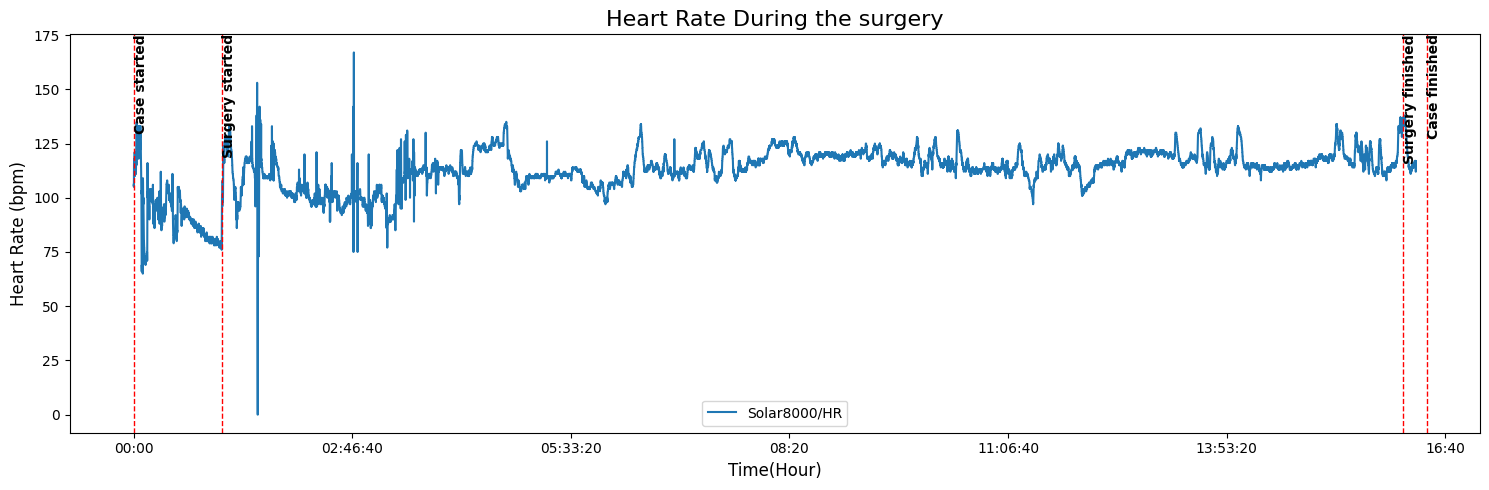



AFTER PRE-PROCESSING




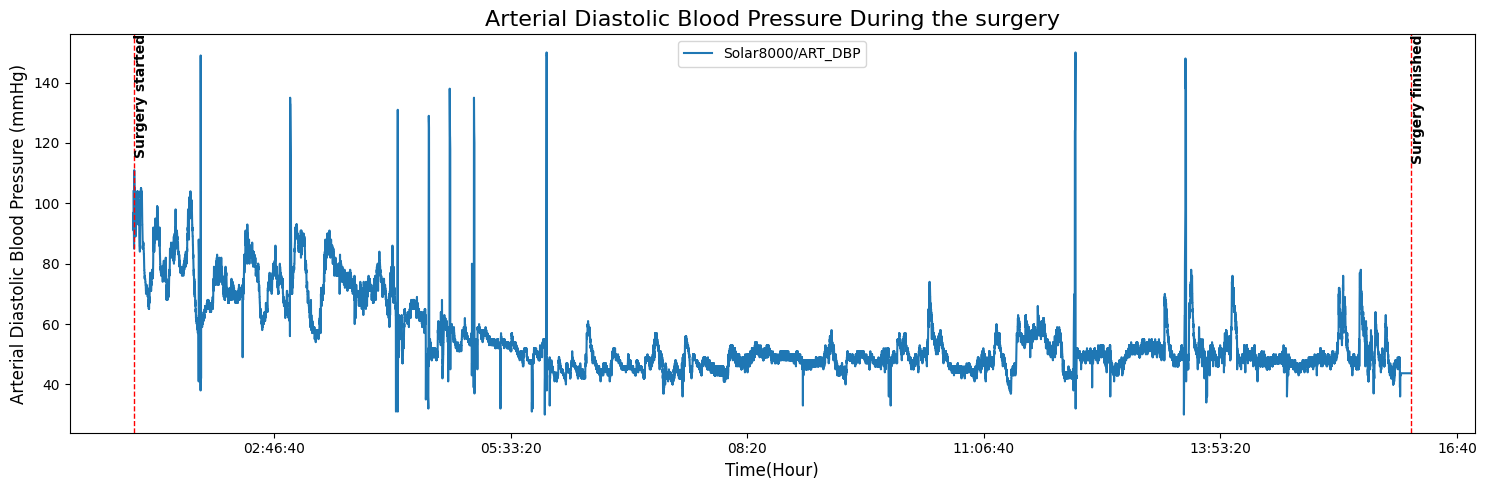

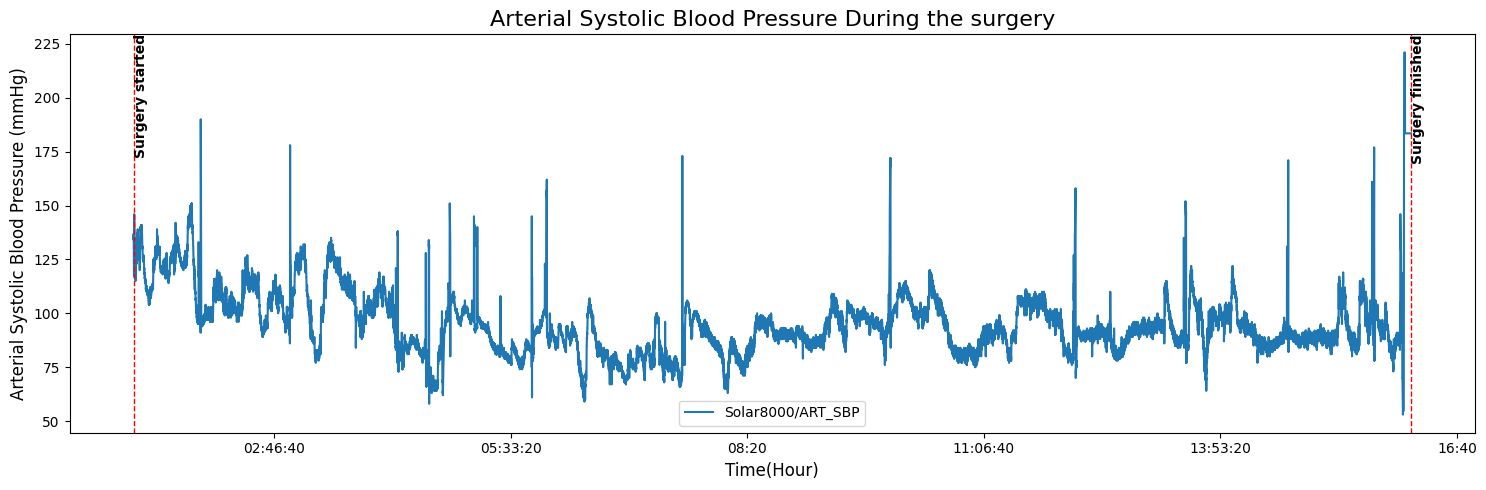

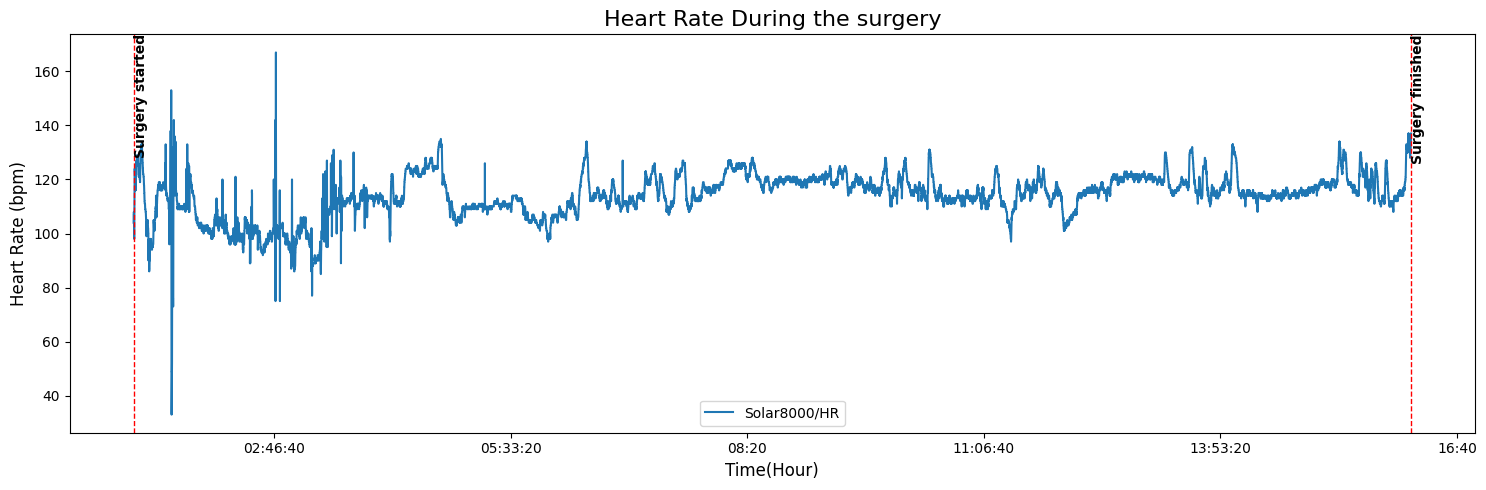

In [17]:
print("BEFORE PRE-PROCESSING\n")
static_plot_vitals(vitals)
print("\n\nAFTER PRE-PROCESSING\n\n")
static_plot_vitals(vitals_no_event)

We can see in the boxplot and statistical description tables, that the preprocessing has successfully:
- Applied sensible ranges for the vital signs.
- Imputed nan values, depending on the duration of consecutive nan values.

## Upper/lower limit values:
---

| Signal | Lower Bound | Upper Bound | Source                     |
|--------|-------------|-------------|----------------------------|
| HR     | 30 bpm      | 180 bpm     | AHA Guidelines, PhysioNet  |
| SBP    | 50 mmHg     | 250 mmHg    | AAMI Standards, ICU datasets |
| DBP    | 30 mmHg     | 150 mmHg    | AAMI, PhysioNet            |



## Solar8000 Data Loss and Spikes:

---

### **Normal vs. Abnormal Durations**

| **Parameter** | **Normal Artifact/Spike Duration** | **Abnormal Duration** | **Causes** |
| :-- | :-- | :-- | :-- |
| **Heart Rate (HR)** | <10 seconds[^5] | >30 seconds[^5] | - **Normal**: Motion artifacts, lead reseating[^4]<br>- **Abnormal**: Arrhythmia events (e.g., sustained VT), TRAM module failure[^3] |
| **Systolic ABP** | <15 seconds[^5] | >60 seconds[^5] | - **Normal**: Catheter flushing[5]<br>- **Abnormal**: Pressure sensor faults, network IP conflicts causing data loss[^3] |
| **Diastolic ABP** | <15 seconds[^3] | >60 seconds[^3] | - **Normal**: Damped waveforms during patient movement[^3]<br>- **Abnormal**: Disconnected transducer, air bubbles in line[^3] |

---
<div>⁂</div>

[^1]: https://pubmed.ncbi.nlm.nih.gov/35957328/

[^2]: https://sites.nd.edu/gonzalo-martinez/files/2020/03/HeartImp_SDM20201.pdf

[^3]: https://avobus.com/pdf/GE/GEHC-Solar8000M-Service.pdf

[^4]: https://support.mindwaretech.com/2016/07/all-about-ecg-part-4-basic-artifact-correction/

[^5]: https://www.piobio.com/wp-content/uploads/2021/06/GE_Solar8000M_MaintenanceCheckout-copy.pdf

**Conclusion**:

- **<15 to 30-second gaps**: Typically benign technical artifacts.
- **>60-second gaps**: Likely indicate critical failures requiring intervention.







In [18]:
create_dynamic_time_series_plot(vitals_no_event, HRT, show_nans=True, file_save=True)
create_dynamic_time_series_plot(vitals_no_event, SYS, show_nans=True, file_save=True)
create_dynamic_time_series_plot(vitals_no_event, DIA, show_nans=True, file_save=True)

Launching server at http://localhost:38235
Launching server at http://localhost:42091
Launching server at http://localhost:35001


# Feature Extraction and Analysis
- Explore the dataset to extract relevant features from the vital sign signals, enhancing the depth of data understanding.
- Using the insights from the previous steps, design and implement an analyzer module capable of summarizing signal data and derived features over specified time frames.

**Deliverable: Analyzer module**

### **Metrics Explanation**

#### **Skewness**

- **Definition**: Skewness measures the symmetry of a data distribution. It indicates whether the data is skewed toward the left or right tail.
- **Types**:
    - **Negative Skewness**: Distribution stretches more toward the left tail (larger values dominate).
    - **Positive Skewness**: Distribution stretches more toward the right tail (smaller values dominate).
    - **Zero Skewness**: Symmetric distribution (e.g., normal distribution).
- **Thresholds**:
    - Values between **-1 and +1** are considered excellent.
    - Values between **-2 and +2** are generally acceptable.
    - Values beyond these ranges indicate substantial non-normality.
- **Applications**:
    - Used in exploratory data analysis to assess data symmetry.
    - Influences preprocessing decisions, such as outlier removal or feature scaling.

---

#### **Kurtosis**

- **Definition**: Kurtosis measures the "tailedness" or peakedness of a distribution compared to a normal distribution.
- **Types**:
    - **Mesokurtic (kurtosis = 3)**: Normal distribution with moderate tails and peak.
    - **Leptokurtic (kurtosis > 3)**: Sharp peak and heavy tails; higher likelihood of extreme values.
    - **Platykurtic (kurtosis < 3)**: Flat peak and light tails; fewer extreme values.
- **Excess Kurtosis**:
    - Defined as \$ kurtosis - 3 \$, treating kurtosis of a normal distribution as zero for interpretability.
- **Thresholds**:
    - Excess kurtosis between **-2 and +2** is generally acceptable.
- **Applications**:
    - Used to identify distributions with extreme values or outliers.
    - Helps in risk assessment and anomaly detection in fields like finance and healthcare.

---
#### **Coefficient of Variation (CV)**

- **Definition**:
$$
CV = \frac{\text{Standard Deviation}}{\text{Mean}} \times 100\%
$$
A **unitless measure** of relative variability.
- **Surgical Applications**:

    - **BP Stability**: 
        - Low BP CV:  
            Stable BP: Consistent readings with minimal fluctuations.
        - High BP CV:  
            Excessive fluctuations in BP over time

    - **HR Stability**: 
        - Low HR CV: Expected under stable anesthesia (autonomic suppression). Concerning if it's sudden (e.g., bradycardia with hypotension).
        
        - High HR CV:  
            Stress Response: May indicate inadequate analgesia.

---

### **SBP - DBP (Pulse Pressure)**

#### **Definition**

*"The difference between systolic and diastolic blood pressures"*

- **Source**: StatPearls (NCBI Bookshelf) defines pulse pressure as SBP – DBP[^1][^7].


#### **Normal Range**

*"Typically 30–50 mmHg"*

- **Source**: Normal PP is ~40 mmHg (120/80 mmHg)[^2][^5][^7]. Studies report mean PP as 41.8–45.6 mmHg in healthy adults[^3][^4].


#### **Critical Thresholds**

- **<25 mmHg**:
    - **Hypovolemia**: PP <25% of SBP indicates narrowed PP (StatPearls)[^7].
    - **Low Stroke Volume**: PP ≈ SV/Arterial Compliance (StatPearls)[^1][^7].
- **>60 mmHg**:
    - **Arterial Stiffness**: PP ≥60 mmHg linked to cardiovascular risk (ESC/ESH Guidelines)[^9][^5].
    - **Clinical Threshold**: >65 mmHg predicts mortality (PubMed 11368460)[^4].


#### **Clinical Significance**

- **Arterial Compliance**: PP reflects SV and arterial stiffness (StatPearls)[^7][^5].
- **Surgical Guidance**: PP <25 mmHg suggests hypovolemia (StatPearls)[^1]; PP >60 mmHg requires intervention[^9].

---

### **HR × SBP (Rate-Pressure Product, RPP)**

#### **Definition**

*"Product of HR and SBP"*

- **Source**: RPP = HR × SBP (PubMed 22301391)[^8].


#### **Normal Range During Surgery**

*"12,000–20,000 mmHg·bpm"*

- **Source**:
    - **Stable Anesthesia**: RPP 12,000–20,000 mmHg·bpm (PMC8029839)[^5].
    - **Surgical Stress**: RPP >20,000 during femoral implantation (PMC2505136)[^6].


#### **Critical Thresholds**

- **RPP <12,000**: Anesthesia: Lower RPP (8k–12k) = expected stability.
- **RPP >12,000**:
    - **Ischemia Risk**: Surgery: Moderate RPP (12k–20k) = normal stress response. Elevated RPP correlates with myocardial demand (PubMed 22301391)[^8].
- **RPP >20,000**:
    - **Surgical Stress**: Critical Threshold: RPP >20,000 universally indicates high risk[^6][^5]. Matches cardiovascular strain during intubation/incision (PMC2505136)[^6].


#### **Clinical Significance**

- **Myocardial Demand**: RPP predicts oxygen consumption (PubMed 22301391)[^8].
- **Intraoperative Monitoring**: RPP >20,000 indicates hemodynamic stress (PMC2505136)[^6].

For surgical thresholds, institutional protocols often adapt these general principles (e.g., RPP >20,000 during high-stress steps)[^6][^8].

---

### **Summary Table**

| Parameter | Statement | Source |
| :-- | :-- | :-- |
| **PP <25 mmHg** | Hypovolemia marker | StatPearls[^1] |
| **PP >60 mmHg** | Arterial stiffness | PubMed 11368460[^4] |
| **RPP >12,000** | Ischemia risk | PubMed 22301391[^8] |
| **RPP >20,000** | Surgical stress | PMC2505136[^6] |

**Note**: PP thresholds vary slightly by study (e.g., >65 mmHg in PubMed 11368460[^4] vs. ≥60 mmHg in ESC guidelines[^9]). RPP thresholds are procedure-specific[^6][^8].

<div>⁂</div>

[^1]: https://www.ncbi.nlm.nih.gov/books/NBK482408/

[^2]: https://pubmed.ncbi.nlm.nih.gov/3611771/

[^3]: https://pmc.ncbi.nlm.nih.gov/articles/PMC9760735/

[^4]: https://pubmed.ncbi.nlm.nih.gov/11368460/

[^5]: https://pmc.ncbi.nlm.nih.gov/articles/PMC8029839/

[^6]: https://pmc.ncbi.nlm.nih.gov/articles/PMC2505136/

[^7]: https://pubmed.ncbi.nlm.nih.gov/29494015/

[^8]: https://pubmed.ncbi.nlm.nih.gov/22301391/

[^9]: https://pmc.ncbi.nlm.nih.gov/articles/PMC8686555/

[^10]: https://pubmed.ncbi.nlm.nih.gov/7552876/







### Example of Signal Analysis

In [19]:
df_hr, df_sys, df_dia, df_cross = analyze_vital_signs(vitals_no_event,start_time='1:00:00', end_time='2:00:00')

In [20]:
df_hr

,window_start,window_end,hr_mean,hr_median,hr_min,hr_max,hr_std,hr_var,hr_range,hr_iqr,hr_skew,hr_kurtosis,hr_p25,hr_p75,hr_cv
0,01:00:00,01:10:00,118.15,121.00,98.00,129.00,8.35,69.68,31.00,9.00,-0.91,-0.28,116.00,125.00,0.07
1,01:10:00,01:20:00,113.77,118.00,86.00,133.00,13.43,180.31,47.00,23.00,-0.29,-1.27,103.00,126.00,0.12
2,01:20:00,01:30:00,111.16,116.00,94.00,126.00,8.40,70.60,32.00,13.00,-0.85,-0.70,105.00,118.00,0.08
3,01:30:00,01:40:00,110.87,112.00,33.00,153.00,17.60,309.85,120.00,6.00,-2.29,7.82,110.00,116.00,0.16
4,01:40:00,01:50:00,113.32,110.00,108.00,133.00,4.92,24.18,25.00,8.00,0.97,0.02,109.00,117.00,0.04
5,01:50:00,02:00:00,103.87,103.00,100.00,114.00,3.12,9.76,14.00,2.00,1.68,2.23,102.00,104.00,0.03


In [21]:
df_sys

,window_start,window_end,sbp_mean,sbp_median,sbp_min,sbp_max,sbp_std,sbp_var,sbp_range,sbp_iqr,sbp_skew,sbp_kurtosis,sbp_p25,sbp_p75,sbp_cv
0,01:00:00,01:10:00,127.49,127.00,115.00,146.00,6.84,46.80,31.00,10.00,0.43,-0.16,123.00,133.00,0.05
1,01:10:00,01:20:00,121.40,121.00,104.00,141.00,11.68,136.42,37.00,22.00,0.17,-1.43,110.00,132.00,0.10
2,01:20:00,01:30:00,122.68,122.00,108.00,139.00,6.25,39.06,31.00,7.00,-0.38,-0.13,120.00,127.00,0.05
3,01:30:00,01:40:00,125.45,126.00,114.00,142.00,5.78,33.42,28.00,9.00,0.06,-0.74,120.00,129.00,0.05
4,01:40:00,01:50:00,131.35,126.00,120.00,151.00,9.53,90.81,31.00,18.00,0.52,-1.37,123.00,141.00,0.07
5,01:50:00,02:00:00,104.69,99.00,91.00,190.00,15.00,224.94,99.00,10.00,3.52,14.93,97.00,107.00,0.14


In [22]:
df_dia

,window_start,window_end,dbp_mean,dbp_median,dbp_min,dbp_max,dbp_std,dbp_var,dbp_range,dbp_iqr,dbp_skew,dbp_kurtosis,dbp_p25,dbp_p75,dbp_cv
0,01:00:00,01:10:00,97.59,97.00,85.00,111.00,5.67,32.10,26.00,8.00,0.22,-0.11,94.00,102.00,0.06
1,01:10:00,01:20:00,83.75,83.00,65.00,105.00,13.09,171.36,40.00,26.00,0.26,-1.49,71.00,97.00,0.16
2,01:20:00,01:30:00,83.25,80.00,71.00,99.00,6.93,48.09,28.00,13.00,0.27,-1.29,77.00,90.00,0.08
3,01:30:00,01:40:00,81.48,83.00,68.00,98.00,6.27,39.26,30.00,8.00,-0.50,-0.57,77.00,85.00,0.08
4,01:40:00,01:50:00,86.18,82.00,76.00,104.00,8.72,76.07,28.00,16.00,0.58,-1.25,78.00,94.00,0.10
5,01:50:00,02:00:00,65.59,63.92,38.00,149.00,10.36,107.34,111.00,6.00,3.70,23.72,61.00,67.00,0.16


In [23]:
df_cross

,window_start,window_end,pulse_pressure_mean,pulse_pressure_std,rate_pressure_product_mean,hr_sbp_corr,hr_dbp_corr,sbp_dbp_corr
0,01:00:00,01:10:00,29.90,3.10,15068.39,0.08,0.29,0.89
1,01:10:00,01:20:00,37.64,2.70,13962.20,0.96,0.93,0.98
2,01:20:00,01:30:00,39.43,3.55,13670.31,0.62,0.16,0.86
3,01:30:00,01:40:00,43.97,3.14,13903.28,-0.07,0.13,0.87
4,01:40:00,01:50:00,45.17,2.31,14920.29,0.77,0.78,0.97
5,01:50:00,02:00:00,39.10,10.34,10892.30,0.55,0.18,0.73


For example 

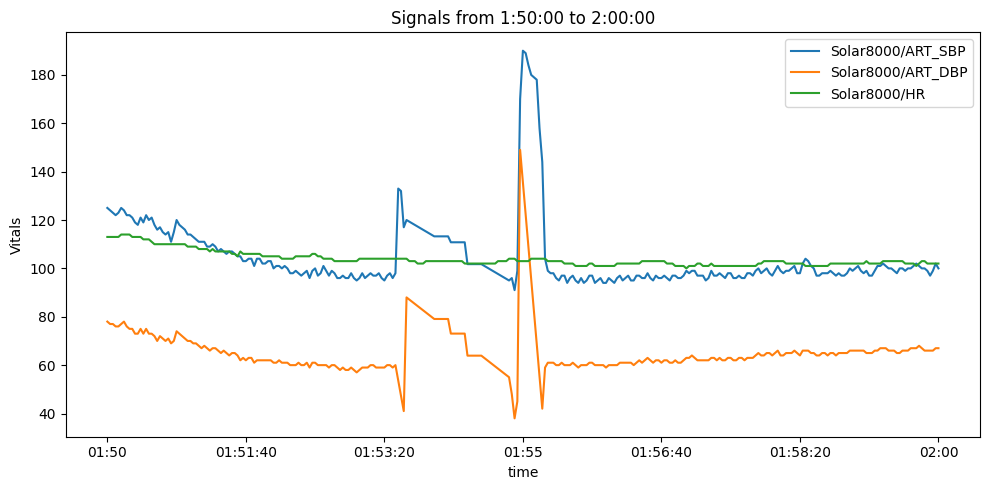

In [24]:
vitals_no_event.loc[time(1,50,00):time(2,00,00), :'Solar8000/HR'].plot(title='Signals from 1:50:00 to 2:00:00',ylabel='Vitals', figsize=(10,5))
plt.legend(loc='best')
plt.tight_layout()

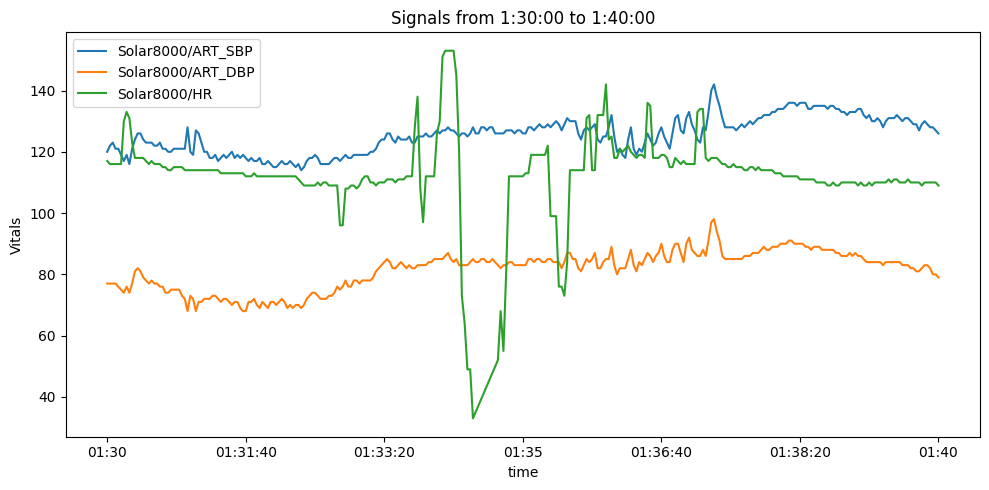

In [25]:
vitals_no_event.loc[time(1,30,00):time(1,40,00), :'Solar8000/HR'].plot(title='Signals from 1:30:00 to 1:40:00',ylabel='Vitals', figsize=(10,5))
plt.tight_layout()

# Discussion and Results